# DETECÇÃO DE LADDER LOGIC BOMB

## Importação de bibliotecas

In [ ]:
%pip install seaborn

import pandas as pd
import numpy as np
from pathlib import Path
import os
import seaborn as sns

from pycaret.classification import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Coleta de dados

In [7]:
BASE_PATH = Path().resolve().parent
DATA_PATH = BASE_PATH / "datasets"

normal_file = DATA_PATH / "dataset_normal.csv"
malicioso_file = DATA_PATH / "dataset_malicious.csv"
df_normal = pd.read_csv(normal_file)
df_malicioso = pd.read_csv(malicioso_file)

## Carregamento dos dados



In [8]:
df_normal = pd.read_csv(normal_file)
df_malicioso = pd.read_csv(malicioso_file)

# corrigir orientação
df_normal = df_normal.set_index(df_normal.columns[0]).T.reset_index()
df_malicioso = df_malicioso.set_index(df_malicioso.columns[0]).T.reset_index()

# renomear a coluna do índice
df_normal = df_normal.rename(columns={"index": "arquivo_xml"})
df_malicioso = df_malicioso.rename(columns={"index": "arquivo_xml"})

df_normal.columns.name = None
df_malicioso.columns.name = None

df_normal["label"] = "normal"
df_malicioso["label"] = "malicioso"

df = pd.concat([df_normal, df_malicioso], ignore_index=True)
df.head()


,arquivo_xml,assigned_vars_st,avg_degree,block_add_count,block_ctd_count,block_ctu_count,block_div_count,block_eq_count,block_ge_count,block_gt_count,...,seq_has_ldn,seq_has_out,seq_n_lines,seq_n_unique_opcodes,seq_n_unique_operands,seq_opcode_vocab,st_text_length,task_intervals,task_priorities,written_output_names
0,lassignment.xml,OUT_MV1;OUT_MV2;real_value,2.1111,0,0,0,0,0,0,0,...,1,1,27,8,17,ARG:5;CALL:2;IN:3;LD:3;LDN:3;OUT:1;OUTVAR:4;RET:6,248,T#20ms,0,CYCLE_ON;MV1;MV2
1,lassignment1.xml,OUT_MV1;OUT_MV2;i;real_value,2.1429,0,0,0,0,0,0,0,...,1,1,20,8,16,ARG:5;CALL:1;IN:4;LD:3;LDN:1;OUT:1;OUTVAR:2;RET:3,319,T#20ms,0,CYCLE_ON;MV1;MV2
2,lexit.xml,OUT_MV1;OUT_MV2;i;real_value,2.1667,0,0,0,0,1,0,0,...,1,1,42,8,22,ARG:9;CALL:4;IN:5;LD:3;LDN:3;OUT:1;OUTVAR:6;RE...,438,T#20ms,0,CYCLE_ON;MV1;MV2
3,lstart_cycle.xml,OUT;OUT_MV1;OUT_MV2;real_value,2.2222,0,0,0,0,0,0,0,...,1,1,31,8,19,ARG:7;CALL:3;IN:4;LD:2;LDN:2;OUT:1;OUTVAR:4;RET:8,273,T#20ms,0,CYCLE_ON;MV1;MV2
4,lstart_cycle1.xml,OUT;OUT_MV1;OUT_MV2;real_value,2.1333,0,0,0,0,0,0,0,...,1,1,25,8,18,ARG:7;CALL:2;IN:5;LD:2;LDN:1;OUT:1;OUTVAR:2;RET:5,290,T#20ms,0,CYCLE_ON;MV1;MV2


In [9]:
# converte atributos com dados numéricos de object para numeric
for col in df.columns:
    if col not in ["arquivo_xml", "label"]:
        converted = pd.to_numeric(df[col], errors="coerce")

        if converted.notna().sum() == df[col].notna().sum():
            df[col] = converted

print(df.dtypes)

arquivo_xml              object
assigned_vars_st         object
avg_degree              float64
block_add_count           int64
block_ctd_count           int64
                         ...   
seq_opcode_vocab         object
st_text_length            int64
task_intervals           object
task_priorities           int64
written_output_names     object
Length: 91, dtype: object


In [10]:
# mapeamento binário da variável target
df["label"] = df["label"].map({
    "normal": 0,
    "malicioso": 1
})

In [ ]:
# =========================================================
# LIMPEZA DOS DADOS
# Mantendo quase todas as features para análise de importância
# Removemos só a sequência crua, se existir
# =========================================================
DROP_COLS = [
    "arquivo_xml",
    "il_like_sequence",
    "assigned_vars_st",
    "block_types",
    "function_block_names",
    "input_var_names",
    "local_var_names",
    "output_var_names",
    "pou_names",
    "seq_opcode_vocab",
    "written_output_names",
    "task_intervals",
    "task_priorities",
]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")

print("\nShape final:", df.shape)
print("\nDistribuição das classes:")
print(df["label"].value_counts())


# =========================================================
# SEPARAÇÃO DAS VARIÁVEIS POR TIPO
# =========================================================

df_modelo = df.copy()
target = "label"

feature_cols = [col for col in df_modelo.columns if col != target]

# Booleanas nativas True/False
bool_features = [
    col for col in feature_cols
    if df_modelo[col].dtype == "bool"
]

# Converte booleanas para 0/1
df_modelo[bool_features] = df_modelo[bool_features].astype(int)

# Numéricas, incluindo booleanas já convertidas
numeric_features = [
    col for col in feature_cols
    if pd.api.types.is_numeric_dtype(df_modelo[col])
]

# Categóricas
categorical_features = [
    col for col in feature_cols
    if df_modelo[col].dtype == "object" or str(df_modelo[col].dtype) == "category"
]

print("Booleanas convertidas para 0/1:")
print(bool_features)

print("\nNuméricas:")
print(numeric_features)

print("\nCategóricas:")
print(categorical_features)



Shape final: (60, 79)

Distribuição das classes:
label
0    30
1    30
Name: count, dtype: int64
Booleanas convertidas para 0/1:
[]

Numéricas:
['avg_degree', 'block_add_count', 'block_ctd_count', 'block_ctu_count', 'block_div_count', 'block_eq_count', 'block_ge_count', 'block_gt_count', 'block_le_count', 'block_lt_count', 'block_mul_count', 'block_ne_count', 'block_sub_count', 'block_tof_count', 'block_ton_count', 'fan_in_max', 'fan_out_max', 'has_arithmetic', 'has_custom_blocks', 'has_fbd', 'has_feedback_loop', 'has_ld', 'has_loop_construct', 'has_sfc', 'has_st', 'has_threshold_logic', 'logic_depth_approx', 'max_degree', 'n_assignments', 'n_blocks', 'n_bool_inputs', 'n_bool_outputs', 'n_coils', 'n_coils_negated', 'n_comparisons', 'n_conditionals_total', 'n_connections', 'n_constants', 'n_contacts', 'n_contacts_negated', 'n_derived_local_vars', 'n_end_if', 'n_end_while', 'n_false_literals', 'n_function_blocks', 'n_if', 'n_inVariables', 'n_inputs', 'n_int_inputs', 'n_int_outputs', 'n_

## Exploratory Data Analysis

In [13]:
#verificando o número de dados faltantes, em qual categoria se encontram e sua proporção no dataset
print('Dataset:\n', df.isnull().sum())
proporcao = df.isnull().sum().sum() / len(df)
print('\nproporção faltante', proporcao)

Dataset:
 avg_degree               0
block_add_count          0
block_ctd_count          0
block_ctu_count          0
block_div_count          0
                        ..
seq_has_out              0
seq_n_lines              0
seq_n_unique_opcodes     0
seq_n_unique_operands    0
st_text_length           0
Length: 79, dtype: int64

proporção faltante 0.0



Features sem correlação:
['block_add_count', 'block_ctd_count', 'block_ctu_count', 'block_div_count', 'block_mul_count', 'block_ne_count', 'block_tof_count', 'block_ton_count', 'fan_in_max', 'has_custom_blocks', 'has_fbd', 'has_feedback_loop', 'has_ld', 'has_sfc', 'has_st', 'has_threshold_logic', 'n_blocks', 'n_coils', 'n_coils_negated', 'n_connections', 'n_left_power_rails', 'n_outVariables', 'n_outputs_written', 'n_physical_inputs', 'n_physical_outputs', 'n_programs', 'n_right_power_rails', 'n_tasks', 'n_unique_blocks', 'outputs_multi_write', 'seq_has_call', 'seq_has_ld', 'seq_has_ldn', 'seq_has_out', 'seq_n_lines', 'seq_n_unique_opcodes', 'seq_n_unique_operands']

Total: 37 features


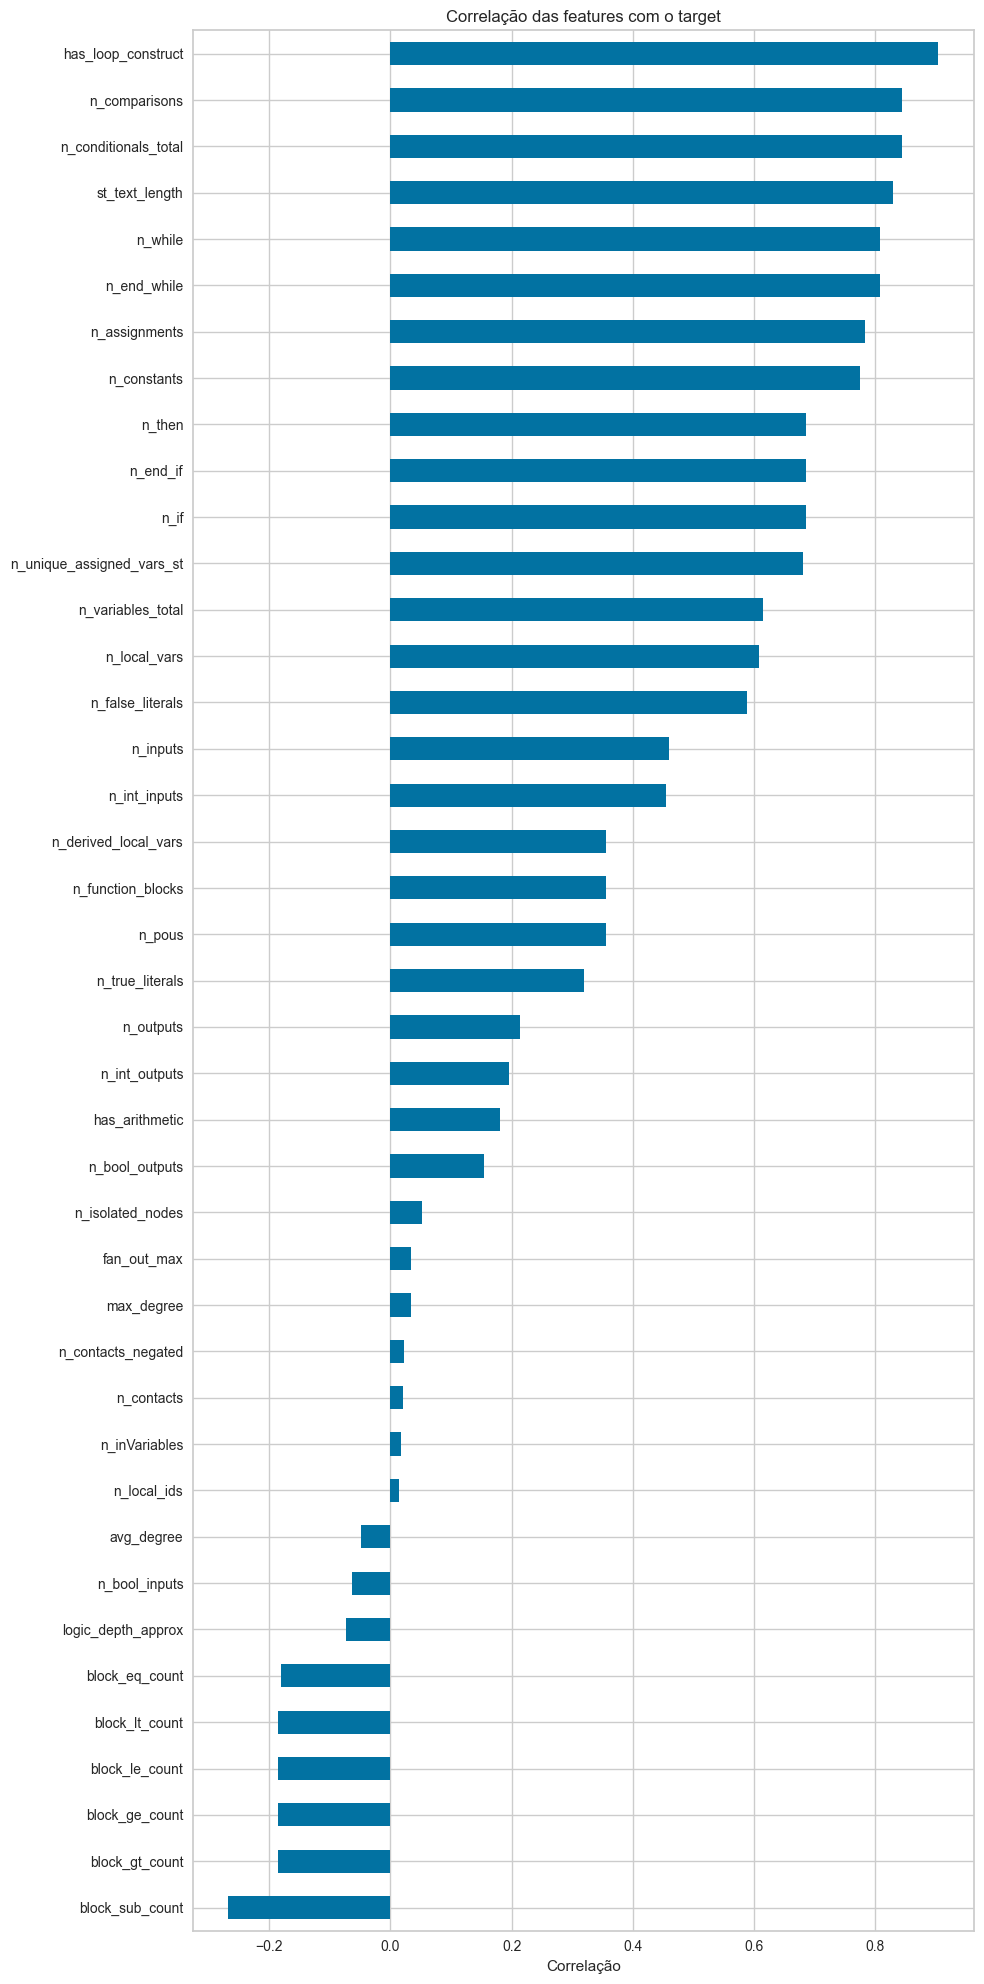

In [14]:
###################################################################
### Avaliação gráfica da correlação entre as variáveis e target ###
###################################################################

# separar numéricas
dados_numericos = df.select_dtypes(include='number')

# separar target
y = dados_numericos["label"]
X = dados_numericos.drop(columns=["label"])

# correlação com target
corr_target = X.corrwith(y)

# separar variaveis com correlação fraca
threshold = 0.01

no_corr_features = corr_target[
    (corr_target.abs() < threshold) | (corr_target.isna())
].index.tolist()
print("\nFeatures sem correlação:")
print(no_corr_features)
print(f"\nTotal: {len(no_corr_features)} features")


# remover no_corr_features
corr_plot = corr_target.drop(index=no_corr_features).sort_values()

# ordenar
plt.figure(figsize=(10, 20))  
corr_plot.plot(kind="barh")
plt.title("Correlação das features com o target")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()


## Pré-processamento

In [ ]:
# Definição dos grupos de atributos

FEATURE_GROUPS = {
    "estruturais": [
        "avg_degree",
        "n_nodes",
        "n_edges",
        "n_isolated_nodes",
        "n_left_power_rails",
        "n_pous",
        "n_function_blocks",
        "n_inputs",
        "n_outputs",
        "n_local_vars",
        "n_local_ids",
        "n_inVariables",
        "n_outVariables",
        "n_int_inputs",
        "n_int_outputs",
        "n_physical_inputs",
        "n_physical_outputs",
        "n_outputs_written",
    ],

    "logicas": [
        "n_conditionals_total",
        "n_comparisons",
        "n_if",
        "n_end_if",
        "n_while",
        "n_end_while",
        "has_loop_construct",
        "n_true_literals",
        "n_false_literals",
    ],

    "semanticas": [
        "st_text_length",
        "n_constants",
        "n_assignments",
        "n_variables",
        "n_functions",
        "n_function_calls",
    ],

    "sequenciais": [
        "seq_n_lines",
        "seq_n_unique_opcodes",
        "seq_n_unique_operands",
        "seq_has_ld",
        "seq_has_ldn",
        "seq_has_out",
        "seq_has_call",
    ],
}

In [40]:
# Função de avaliação por grupo
from sklearn.model_selection import cross_validate
def avaliar_grupos_cv(df, feature_groups, target="label", n_splits=5):
    resultados = []

    y = df[target].astype(int)

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    }

    for grupo, features in feature_groups.items():
        features_validas = [
            f for f in features
            if f in df.columns
        ]

        if len(features_validas) == 0:
            print(f"Grupo ignorado: {grupo} sem features válidas")
            continue

        X = df[features_validas].copy()

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced"
        )

        scores = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )

        resultados.append({
            "grupo": grupo,
            "num_features": len(features_validas),

            "accuracy_mean": np.mean(scores["test_accuracy"]),
            "accuracy_std": np.std(scores["test_accuracy"]),

            "precision_mean": np.mean(scores["test_precision"]),
            "precision_std": np.std(scores["test_precision"]),

            "recall_mean": np.mean(scores["test_recall"]),
            "recall_std": np.std(scores["test_recall"]),

            "f1_mean": np.mean(scores["test_f1"]),
            "f1_std": np.std(scores["test_f1"]),

            "features_usadas": features_validas
        })

    return pd.DataFrame(resultados)

In [41]:
# Função para métricas
def avaliar_modelo(pred_df):
    y_true = pred_df["label"]
    y_pred = pred_df["prediction_label"]

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
    cm,
    index=["true_normal", "true_malicioso"],
    columns=["pred_normal", "pred_malicioso"]
    )   

    print("\n Matriz de confusão:")
    print(cm_df)

    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        }
    return metricas

# ANÁLISE SUPERVISIONADA

In [48]:
# =========================================================
# SETUP PYCARET
# - split 80/20
# - 5-fold CV
# =========================================================

exp = setup(
    data=df,
    target="label",
    train_size=0.8,
    fold=5,
    fold_strategy="stratifiedkfold",
    session_id=42,
    normalize=True,
    html=False,
    verbose=False
)

# =========================================================
# COMPARAÇÃO DE MODELOS
# modelos selecionados manualmente
# =========================================================
best_model = compare_models(
    include=[
        "lr",       # Logistic Regression
        "rf",       # Random Forest
        "et",       # Extra Trees
        "mlp",      # MLP Classifier
        "gbc",      # Gradient Boosting Classifier 
        "lightgbm", # LightGBM
        "svm",      # SVM
    ],
    sort = 'F1'
);


                                    Model  Accuracy    AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.9356  1.000    0.96  0.9267   
lr                    Logistic Regression    0.9156  0.934    0.92  0.9267   
gbc          Gradient Boosting Classifier    0.8956  0.915    0.92  0.8767   
et                 Extra Trees Classifier    0.8956  0.951    0.88  0.9267   
svm                   SVM - Linear Kernel    0.8778  0.958    0.84  0.9333   
mlp                        MLP Classifier    0.8556  0.918    0.84  0.8933   
lightgbm  Light Gradient Boosting Machine    0.4778  0.500    0.20  0.0889   

              F1   Kappa     MCC  TT (Sec)  
rf        0.9374  0.8699  0.8814     0.500  
lr        0.9096  0.8299  0.8490     0.438  
gbc       0.8929  0.7899  0.7998     0.374  
et        0.8874  0.7899  0.8123     0.540  
svm       0.8557  0.7538  0.7847     0.012  
mlp       0.8414  0.7099  0.7433     0.476  
lightgbm  0.1231  0.0000  0.0000     0.016  


## Importância das features

                      Model  Accuracy  AUC  Recall  Prec.   F1  Kappa  MCC
0  Random Forest Classifier       1.0  1.0     1.0    1.0  1.0    1.0  1.0

Matriz de confusão:
        pred_0  pred_1
true_0       6       0
true_1       0       6

Relatório de classificação:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00         6
   malicious       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


Métricas:
   accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  \
0       1.0              1.0           1.0       1.0                 1.0   

   recall_weighted  f1_weighted  
0              1.0          1.0  


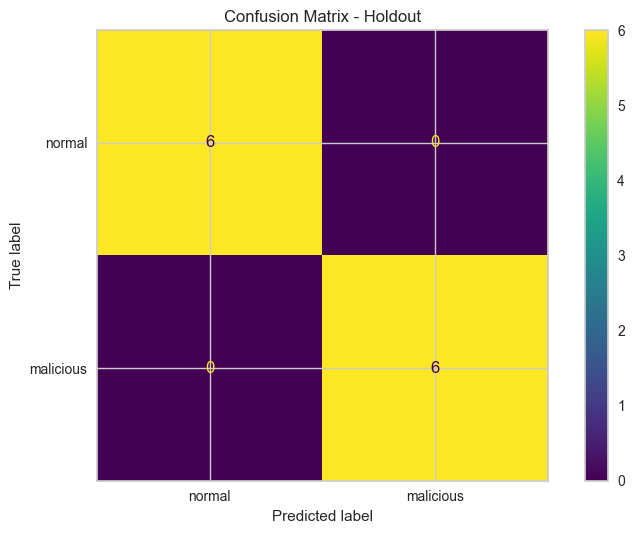

In [49]:
# Predição nos 20% de holdout interno do PyCaret
holdout_pred = predict_model(best_model)

y_true = holdout_pred["label"].to_numpy().astype(int)
y_pred = holdout_pred["prediction_label"].to_numpy().astype(int)

labels = [0, 1]

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred, labels=labels)

cm_df = pd.DataFrame(
    cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
)

print("\nMatriz de confusão:")
print(cm_df)

print("\nRelatório de classificação:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=["normal", "malicious"],
        zero_division=0
    )
)

# Métricas principais
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
}

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv("metrics_holdout.csv", index=False)

print("\nMétricas:")
print(metrics_df)

# Gráfico da matriz de confusão
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["normal", "malicious"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Holdout")
plt.tight_layout()
plt.show()

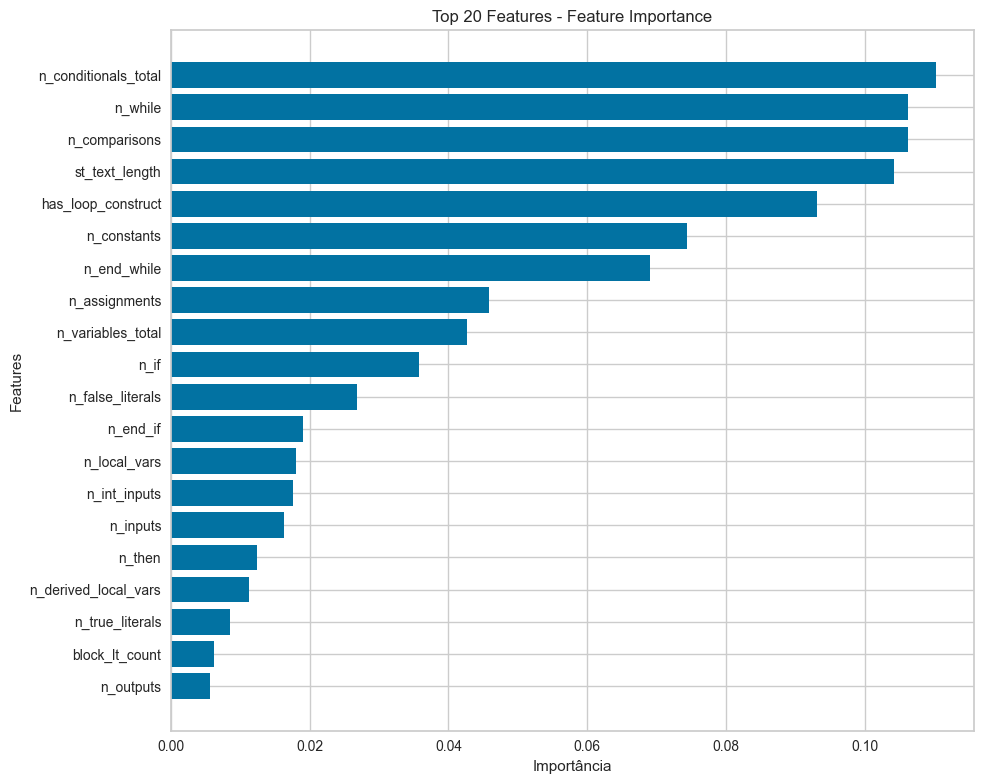

In [50]:
# =========================================================
# IMPORTÂNCIA DAS FEATURES DO RANDOM FOREST
# =========================================================
# métricas do melhor modelo (última tabela do compare_models)

importances = best_model.feature_importances_

X_test = df.drop(columns=["label"], errors="ignore")

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.ylabel("Features")
plt.title("Top 20 Features - Feature Importance")
plt.tight_layout()
plt.show()


# ANÁLISE NÃO SUPERVISIONADA

In [51]:
# =========================================================
# ANÁLISE POR GRUPOS DE FEATURES
# =========================================================

resultados_cv = avaliar_grupos_cv(
    df=df,
    feature_groups=FEATURE_GROUPS,
    target="label",
    n_splits=5
)

print(resultados_cv[[
    "grupo",
    "num_features",
    "accuracy_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "f1_std"
]])

         grupo  num_features  accuracy_mean  precision_mean  recall_mean  \
0  estruturais            16       0.800000        0.780952     0.833333   
1      logicas             9       0.966667        0.942857     1.000000   
2   semanticas             3       0.966667        0.942857     1.000000   
3  sequenciais             7       0.216667        0.222143     0.266667   

    f1_mean    f1_std  
0  0.796557  0.109920  
1  0.969231  0.037684  
2  0.969231  0.037684  
3  0.240759  0.143676  


In [28]:
for grupo, features in FEATURE_GROUPS.items():
    features_validas = [
        f for f in features
        if f in df_treino.columns and f in df_teste.columns
    ]
    print(grupo, len(features_validas), features_validas)

estruturais 16 ['avg_degree', 'n_isolated_nodes', 'n_left_power_rails', 'n_pous', 'n_function_blocks', 'n_inputs', 'n_outputs', 'n_local_vars', 'n_local_ids', 'n_inVariables', 'n_outVariables', 'n_int_inputs', 'n_int_outputs', 'n_physical_inputs', 'n_physical_outputs', 'n_outputs_written']
logicas 9 ['n_conditionals_total', 'n_comparisons', 'n_if', 'n_end_if', 'n_while', 'n_end_while', 'has_loop_construct', 'n_true_literals', 'n_false_literals']
semanticas_leves 3 ['st_text_length', 'n_constants', 'n_assignments']
sequenciais 0 []


In [2]:
df = pd.DataFrame({
    'feature': [1, 2, 3, 4, 5, 6],
    'group': [1, 1, 2, 2, 3, 3] # Grupos: 1, 2, 3
})

In [3]:
df.head(10)


,feature,group
0,1,1
1,2,1
2,3,2
3,4,2
4,5,3
5,6,3


In [34]:
a = np.array([[1, 111], [2,22]])
a

array([[  1, 111],
       [  2,  22]])

In [25]:
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

gss = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=42)
for train_idx, test_idx in gss.split(df, groups=df['group']):
    train_data = df.iloc[train_idx]
    test_data = df.iloc[test_idx]

# CLUSTERIZAÇÃO


PROCESSANDO GRUPO: estruturais
Removendo colunas constantes: ['n_left_power_rails', 'n_physical_inputs', 'n_physical_outputs']
Variância explicada PCA: 0.6249
Número de clusters: 7
Noise ratio: 0.2167

Distribuição percentual por cluster:
label           0         1
cluster                    
-1       0.384615  0.615385
 0       0.600000  0.400000
 1       0.666667  0.333333
 2       0.500000  0.500000
 3       0.857143  0.142857
 4       1.000000  0.000000
 5       0.000000  1.000000
 6       0.000000  1.000000

Contagem absoluta:
label    0  1
cluster      
-1       5  8
 0       3  2
 1       6  3
 2       5  5
 3       6  1
 4       5  0
 5       0  6
 6       0  5

Métricas:
Silhouette: 0.8054960806562941
Davies-Bouldin: 0.3229972151920601
Calinski-Harabasz: 345.1524637133312

Top features discriminantes:
['n_local_ids', 'n_int_inputs', 'n_outputs', 'n_outVariables', 'n_inputs']


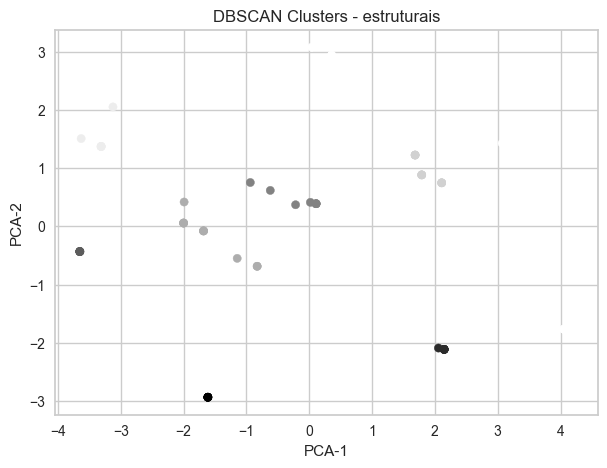

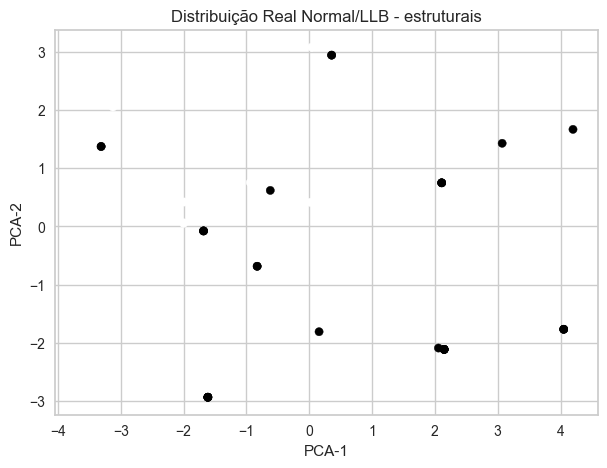


PROCESSANDO GRUPO: logicas
Variância explicada PCA: 0.8891
Número de clusters: 5
Noise ratio: 0.1667

Distribuição percentual por cluster:
label      0    1
cluster          
-1       0.4  0.6
 0       1.0  0.0
 1       0.2  0.8
 2       1.0  0.0
 3       0.0  1.0
 4       0.0  1.0

Contagem absoluta:
label     0   1
cluster        
-1        4   6
 0       13   0
 1        1   4
 2       12   0
 3        0  13
 4        0   7

Métricas:
Silhouette: 0.8529212146885585
Davies-Bouldin: 0.21547042966595797
Calinski-Harabasz: 929.8519676264613

Top features discriminantes:
['n_comparisons', 'n_conditionals_total', 'n_if', 'n_end_if', 'n_false_literals']


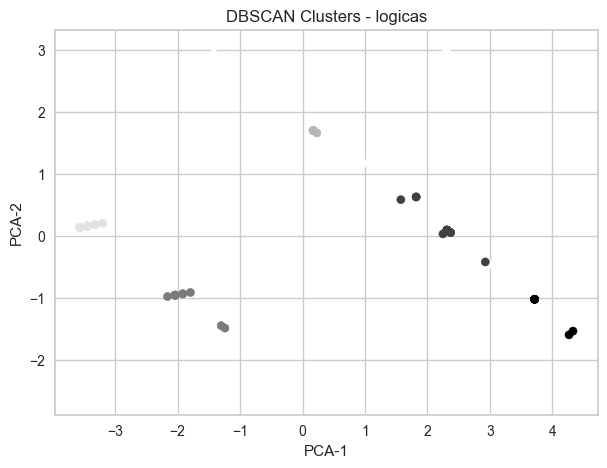

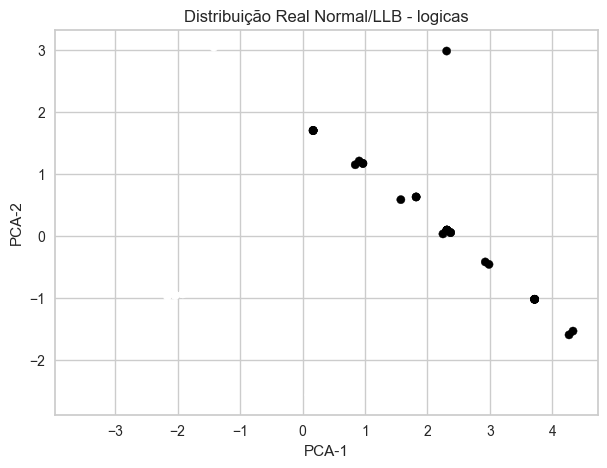


PROCESSANDO GRUPO: semanticas_leves
Variância explicada PCA: 0.9919
Número de clusters: 2
Noise ratio: 0.0167

Distribuição percentual por cluster:
label         0       1
cluster                
-1       1.0000  0.0000
 0       1.0000  0.0000
 1       0.0625  0.9375

Contagem absoluta:
label     0   1
cluster        
-1        1   0
 0       27   0
 1        2  30

Métricas:
Silhouette: 0.6963414484751608
Davies-Bouldin: 0.4047410274273531
Calinski-Harabasz: 235.0662300422395

Top features discriminantes:
['st_text_length', 'n_constants', 'n_assignments']


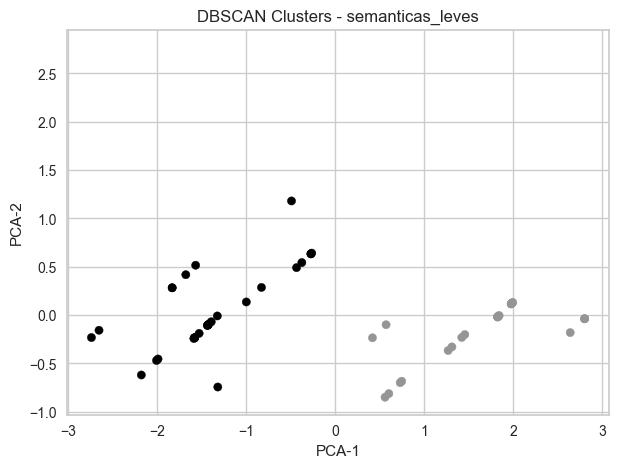

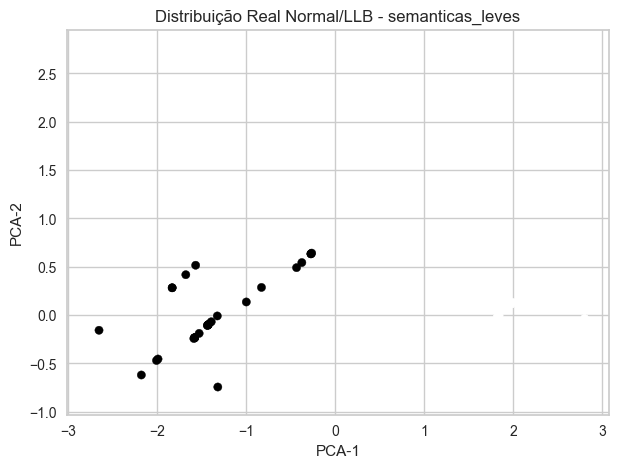


PROCESSANDO GRUPO: sequenciais
Removendo colunas constantes: ['seq_has_ld', 'seq_has_call']
Variância explicada PCA: 0.7661
Número de clusters: 2
Noise ratio: 0.2

Distribuição percentual por cluster:
label           0         1
cluster                    
-1       0.500000  0.500000
 0       0.454545  0.545455
 1       0.513514  0.486486

Contagem absoluta:
label     0   1
cluster        
-1        6   6
 0        5   6
 1       19  18

Métricas:
Silhouette: 0.6489472227541491
Davies-Bouldin: 0.38532629242541183
Calinski-Harabasz: 82.16749060203963

Top features discriminantes:
['seq_n_lines', 'seq_n_unique_operands', 'seq_n_unique_opcodes', 'seq_has_out', 'seq_has_ldn']


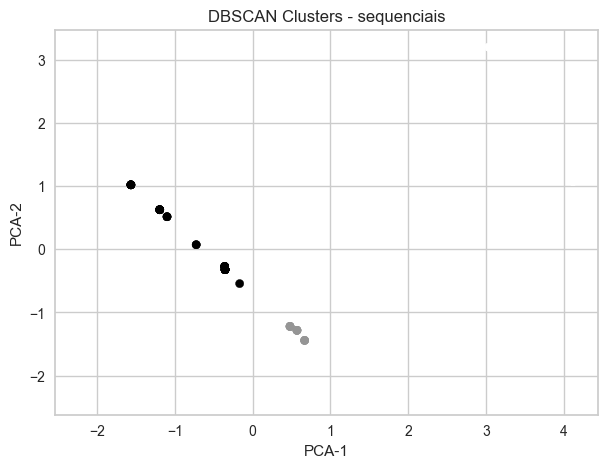

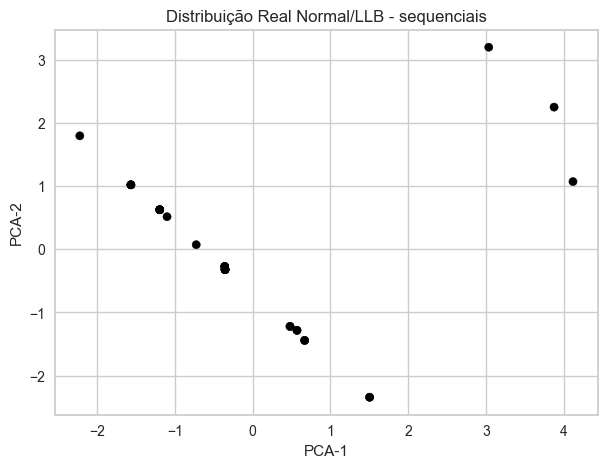


RESULTADO FINAL


,grupo,n_features,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz,explained_variance_pca,top_features
0,estruturais,13,7,0.216667,0.805496,0.322997,345.152464,0.624933,"n_local_ids, n_int_inputs, n_outputs, n_outVar..."
1,logicas,9,5,0.166667,0.852921,0.215470,929.851968,0.889113,"n_comparisons, n_conditionals_total, n_if, n_e..."
2,semanticas_leves,3,2,0.016667,0.696341,0.404741,235.066230,0.991940,"st_text_length, n_constants, n_assignments"
3,sequenciais,5,2,0.200000,0.648947,0.385326,82.167491,0.766137,"seq_n_lines, seq_n_unique_operands, seq_n_uniq..."


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ============================================================
# FEATURE GROUPS
# ============================================================

FEATURE_GROUPS = {

    "estruturais": [
        "avg_degree",
        "n_nodes",
        "n_edges",
        "n_isolated_nodes",
        "n_left_power_rails",
        "n_pous",
        "n_function_blocks",
        "n_inputs",
        "n_outputs",
        "n_local_vars",
        "n_local_ids",
        "n_inVariables",
        "n_outVariables",
        "n_int_inputs",
        "n_int_outputs",
        "n_physical_inputs",
        "n_physical_outputs",
        "n_outputs_written",
    ],

    "logicas": [
        "n_conditionals_total",
        "n_comparisons",
        "n_if",
        "n_end_if",
        "n_while",
        "n_end_while",
        "has_loop_construct",
        "n_true_literals",
        "n_false_literals",
    ],

    "semanticas": [
        "st_text_length",
        "n_constants",
        "n_assignments",
        "n_variables",
        "n_functions",
        "n_function_calls",
    ],

    "sequenciais": [
        "seq_n_lines",
        "seq_n_unique_opcodes",
        "seq_n_unique_operands",
        "seq_has_ld",
        "seq_has_ldn",
        "seq_has_out",
        "seq_has_call",
    ],
}

# ============================================================
# LABEL
# ============================================================

LABEL_COLUMN = "label"

labels = df[LABEL_COLUMN].copy()

# ============================================================
# RESULTADOS
# ============================================================

results = []

cluster_outputs = {}

# ============================================================
# LOOP PRINCIPAL
# ============================================================

for group_name, features in FEATURE_GROUPS.items():

    print("\n===================================================")
    print(f"PROCESSANDO GRUPO: {group_name}")
    print("===================================================")

    # --------------------------------------------------------
    # Seleciona apenas features existentes
    # --------------------------------------------------------

    existing_features = [f for f in features if f in df.columns]

    if len(existing_features) == 0:
        print("Nenhuma feature encontrada.")
        continue

    X = df[existing_features].copy()

    # --------------------------------------------------------
    # Apenas numéricas
    # --------------------------------------------------------

    X = X.apply(pd.to_numeric, errors="coerce")

    X = X.fillna(0)

    # --------------------------------------------------------
    # Remove colunas constantes
    # --------------------------------------------------------

    constant_cols = [c for c in X.columns if X[c].nunique() <= 1]

    if constant_cols:
        print("Removendo colunas constantes:", constant_cols)
        X = X.drop(columns=constant_cols)

    if X.shape[1] == 0:
        print("Grupo sem features válidas.")
        continue

    # --------------------------------------------------------
    # Normalização
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    # --------------------------------------------------------
    # PCA
    # --------------------------------------------------------

    pca = PCA(n_components=2)

    X_pca = pca.fit_transform(X_scaled)

    explained_variance = pca.explained_variance_ratio_.sum()

    print(f"Variância explicada PCA: {explained_variance:.4f}")

    # --------------------------------------------------------
    # DBSCAN
    # --------------------------------------------------------

    dbscan = DBSCAN(
        eps=0.8,
        min_samples=5
    )

    clusters = dbscan.fit_predict(X_pca)

    # --------------------------------------------------------
    # DataFrame auxiliar
    # --------------------------------------------------------

    output = pd.DataFrame({
        "label": labels.values,
        "cluster": clusters,
        "pca_1": X_pca[:, 0],
        "pca_2": X_pca[:, 1],
    })

    cluster_outputs[group_name] = output

    # --------------------------------------------------------
    # Estatísticas básicas
    # --------------------------------------------------------

    n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

    noise_ratio = np.mean(clusters == -1)

    print("Número de clusters:", n_clusters)

    print("Noise ratio:", round(noise_ratio, 4))

    # --------------------------------------------------------
    # Distribuição label x cluster
    # --------------------------------------------------------

    cluster_label_dist = pd.crosstab(
        output["cluster"],
        output["label"],
        normalize="index"
    )

    print("\nDistribuição percentual por cluster:")
    print(cluster_label_dist)

    cluster_label_count = pd.crosstab(
        output["cluster"],
        output["label"]
    )

    print("\nContagem absoluta:")
    print(cluster_label_count)

    # --------------------------------------------------------
    # Métricas internas
    # --------------------------------------------------------

    if n_clusters > 1:

        mask = clusters != -1

        sil = silhouette_score(
            X_pca[mask],
            clusters[mask]
        )

        dbi = davies_bouldin_score(
            X_pca[mask],
            clusters[mask]
        )

        ch = calinski_harabasz_score(
            X_pca[mask],
            clusters[mask]
        )

    else:

        sil = np.nan
        dbi = np.nan
        ch = np.nan

    print("\nMétricas:")

    print("Silhouette:", sil)

    print("Davies-Bouldin:", dbi)

    print("Calinski-Harabasz:", ch)

    # --------------------------------------------------------
    # Features mais discriminantes
    # --------------------------------------------------------

    temp = X.copy()

    temp["cluster"] = clusters

    cluster_means = temp.groupby("cluster").mean()

    feature_variance = (
        cluster_means.var()
        .sort_values(ascending=False)
    )

    top_features = feature_variance.head(5).index.tolist()

    print("\nTop features discriminantes:")
    print(top_features)

    # --------------------------------------------------------
    # Salva resultados
    # --------------------------------------------------------

    results.append({
        "grupo": group_name,
        "n_features": X.shape[1],
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": sil,
        "davies_bouldin": dbi,
        "calinski_harabasz": ch,
        "explained_variance_pca": explained_variance,
        "top_features": ", ".join(top_features)
    })

    # --------------------------------------------------------
    # Plot clusters
    # --------------------------------------------------------

    plt.figure(figsize=(7, 5))

    plt.scatter(
        output["pca_1"],
        output["pca_2"],
        c=output["cluster"],
        s=35
    )

    plt.title(f"DBSCAN Clusters - {group_name}")

    plt.xlabel("PCA-1")

    plt.ylabel("PCA-2")

    plt.grid(True)

    plt.show()

    # --------------------------------------------------------
    # Plot labels reais
    # --------------------------------------------------------

    plt.figure(figsize=(7, 5))

    plt.scatter(
        output["pca_1"],
        output["pca_2"],
        c=output["label"],
        s=35
    )

    plt.title(f"Distribuição Real Normal/LLB - {group_name}")

    plt.xlabel("PCA-1")

    plt.ylabel("PCA-2")

    plt.grid(True)

    plt.show()

# ============================================================
# RESULTADO FINAL
# ============================================================

results_df = pd.DataFrame(results)

print("\n===================================================")
print("RESULTADO FINAL")
print("===================================================")

display(results_df)


In [49]:

# =========================================================
# TABELA-RESUMO DA CLUSTERIZAÇÃO
# =========================================================
cluster_table = results_df[[
    "grupo",
    "n_features",
    "explained_variance_pca",
    "n_clusters",
    "noise_ratio",
    "silhouette",
    "davies_bouldin",
    "top_features"
]].copy()

cluster_table = cluster_table.rename(columns={
    "grupo": "Grupo",
    "n_features": "Nº features",
    "explained_variance_pca": "Variância PCA",
    "n_clusters": "Nº clusters",
    "noise_ratio": "Ruído (%)",
    "silhouette": "Silhouette",
    "davies_bouldin": "Davies-Bouldin",
    "top_features": "Principais features"
})

# formatação
cluster_table["Variância PCA"] = cluster_table["Variância PCA"].round(4)
cluster_table["Ruído (%)"] = (cluster_table["Ruído (%)"] * 100).round(2)
cluster_table["Silhouette"] = cluster_table["Silhouette"].round(4)
cluster_table["Davies-Bouldin"] = cluster_table["Davies-Bouldin"].round(4)

print(cluster_table)
cluster_table.to_csv("clusterizacao_resumo.csv", index=False)

              Grupo  Nº features  Variância PCA  Nº clusters  Ruído (%)  \
0       estruturais           13         0.6249            7      21.67   
1           logicas            9         0.8891            5      16.67   
2  semanticas_leves            3         0.9919            2       1.67   
3       sequenciais            5         0.7661            2      20.00   

   Silhouette  Davies-Bouldin  \
0      0.8055          0.3230   
1      0.8529          0.2155   
2      0.6963          0.4047   
3      0.6489          0.3853   

                                 Principais features  
0  n_local_ids, n_int_inputs, n_outputs, n_outVar...  
1  n_comparisons, n_conditionals_total, n_if, n_e...  
2         st_text_length, n_constants, n_assignments  
3  seq_n_lines, seq_n_unique_operands, seq_n_uniq...  


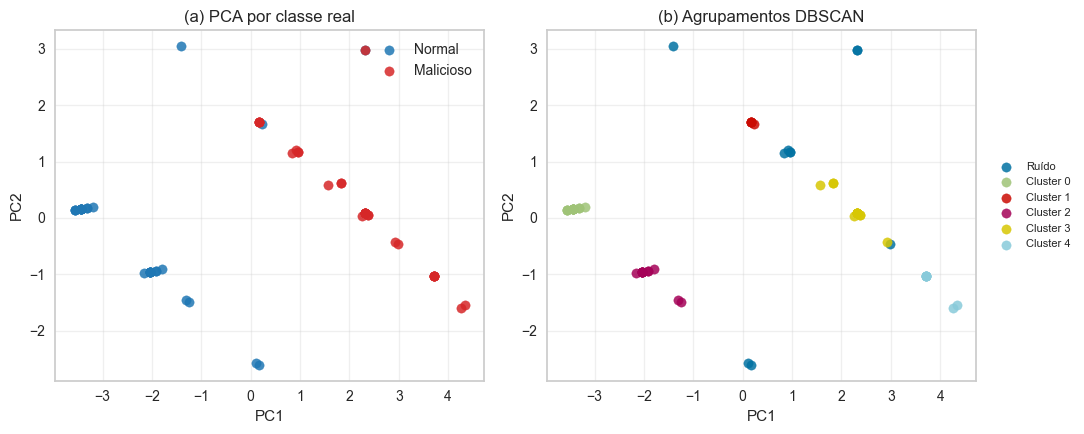

In [52]:
# =========================================================
# ESCOLHA DO GRUPO MAIS REPRESENTATIVO
# =========================================================
grupo_representativo = "logicas"

# pegar o dataframe já gerado no seu pipeline
pca_df = cluster_outputs[grupo_representativo].copy()

# =========================================================
# AJUSTE DA LEGENDA DAS CLASSES
# classe 0 = normal
# classe 1 = malicioso
# =========================================================
label_map = {
    0: "Normal",
    1: "Malicioso",
    "0": "Normal",
    "1": "Malicioso",
    "normal": "Normal",
    "malicioso": "Malicioso"
}

pca_df["label_nome"] = pca_df["label"].map(label_map)

# caso alguma label não entre no mapeamento
pca_df["label_nome"] = pca_df["label_nome"].fillna(pca_df["label"].astype(str))

# =========================================================
# FIGURA COMPOSTA: PCA por classe real + DBSCAN
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# --------------------------------------------
# (a) PCA por classe real
# --------------------------------------------
cores_classes = {
    "Normal": "tab:blue",
    "Malicioso": "tab:red"
}

for nome_classe in ["Normal", "Malicioso"]:
    subset = pca_df[pca_df["label_nome"] == nome_classe]
    if not subset.empty:
        axes[0].scatter(
            subset["pca_1"],
            subset["pca_2"],
            label=nome_classe,
            alpha=0.85,
            s=45,
            color=cores_classes[nome_classe]
        )

axes[0].set_title("(a) PCA por classe real")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

# --------------------------------------------
# (b) PCA por cluster DBSCAN
# --------------------------------------------
for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    nome_cluster = "Ruído" if cluster == -1 else f"Cluster {cluster}"

    axes[1].scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=nome_cluster,
        alpha=0.85,
        s=45
    )

axes[1].set_title("(b) Agrupamentos DBSCAN")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)
axes[1].legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=8
)

plt.tight_layout()
plt.savefig(f"pca_dbscan_{grupo_representativo}.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [28]:
grupo_representativo = "logicas"
pca_df = cluster_outputs[grupo_representativo].copy()

label_map = {
    0: "Normal",
    1: "Malicioso",
    "0": "Normal",
    "1": "Malicioso",
    "normal": "Normal",
    "malicioso": "Malicioso"
}

pca_df["label_nome"] = pca_df["label"].map(label_map)
pca_df["label_nome"] = pca_df["label_nome"].fillna(pca_df["label"].astype(str))

# Contagem absoluta por cluster
cluster_count = pd.crosstab(
    pca_df["cluster"],
    pca_df["label_nome"]
)

print("Contagem por cluster:")
print(cluster_count)

# Percentual por cluster
cluster_percent = pd.crosstab(
    pca_df["cluster"],
    pca_df["label_nome"],
    normalize="index"
).round(4) * 100

print("\nPercentual por cluster:")
print(cluster_percent)

Contagem por cluster:
label_nome  Malicioso  Normal
cluster                      
-1                  6       4
 0                  0      13
 1                  4       1
 2                  0      12
 3                 13       0
 4                  7       0

Percentual por cluster:
label_nome  Malicioso  Normal
cluster                      
-1               60.0    40.0
 0                0.0   100.0
 1               80.0    20.0
 2                0.0   100.0
 3              100.0     0.0
 4              100.0     0.0
